# T0 Baseline Analysis

Covers all 34 T0 episodes:
- **ep0000–ep0013**: sklearn-only toolset (no traces)
- **ep0014–ep0033**: full toolkit (GBMs available); traces from ep0014 onward

Run this notebook *after* the T0 run completes. Functions live in `scripts/trace_analysis.py` — reuse them for T1a/T1b by changing `TREATMENT`.


In [3]:
import sys
sys.path.insert(0, '/home/oliversnavy/repos/ai-lending')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scripts.trace_analysis import (
    load_episodes, load_trace, has_trace,
    treatment_trace_df, detect_models,
    bootstrap_ci, required_n, summary_stats, outlier_report,
    extract_thinking, count_errors, episode_trace_features,
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.3f}".format)

TREATMENT = "0"
df = load_episodes(TREATMENT)
print(f"Loaded {len(df)} episodes for T{TREATMENT}")
df[["episode_id","pnl","c_stat","acceptance_rate","loans_funded","duration_s","tokens_used"]].head(10)


Loaded 34 episodes for T0


,episode_id,pnl,c_stat,acceptance_rate,loans_funded,duration_s,tokens_used
0,0,22045627.357,0.664,0.316,770,2037.300,599766
1,1,19600705.460,0.666,0.123,697,1983.900,455010
2,2,10299517.187,0.667,0.461,581,1570.800,572803
3,3,13267997.067,0.678,0.449,759,1104.600,343298
4,4,22137976.000,0.663,0.307,750,2097.500,409875
5,5,17192455.576,0.664,0.550,759,2472.500,639367
6,6,15577924.891,0.672,0.230,459,2328.500,823658
7,7,14344718.891,0.673,0.548,900,1713.400,535332
8,8,1821023.940,0.678,0.401,401,2320.900,686927
9,9,19739124.613,0.652,0.547,706,2459.100,536387


## 1. Statistical Summary

In [4]:
pnl_stats   = summary_stats(df, "pnl")
cstat_stats = summary_stats(df, "c_stat")

print("=== P&L (USD) ===")
for k, v in pnl_stats.items():
    print(f"  {k:8s}: ${v/1e6:.2f}M" if k not in ("n",) else f"  {k:8s}: {int(v)}")

print("\n=== Harrell's C-stat ===")
for k, v in cstat_stats.items():
    print(f"  {k:8s}: {v:.4f}" if k not in ("n",) else f"  {k:8s}: {int(v)}")


=== P&L (USD) ===
  n       : 34
  mean    : $17.56M
  sd      : $4.79M
  median  : $17.55M
  p10     : $12.41M
  p90     : $22.27M
  ci_lo   : $15.88M
  ci_hi   : $19.06M
  min     : $1.82M
  max     : $22.35M

=== Harrell's C-stat ===
  n       : 34
  mean    : 0.6667
  sd      : 0.0201
  median  : 0.6730
  p10     : 0.6514
  p90     : 0.6806
  ci_lo   : 0.6595
  ci_hi   : 0.6726
  min     : 0.5864
  max     : 0.6839


## 2. Distribution

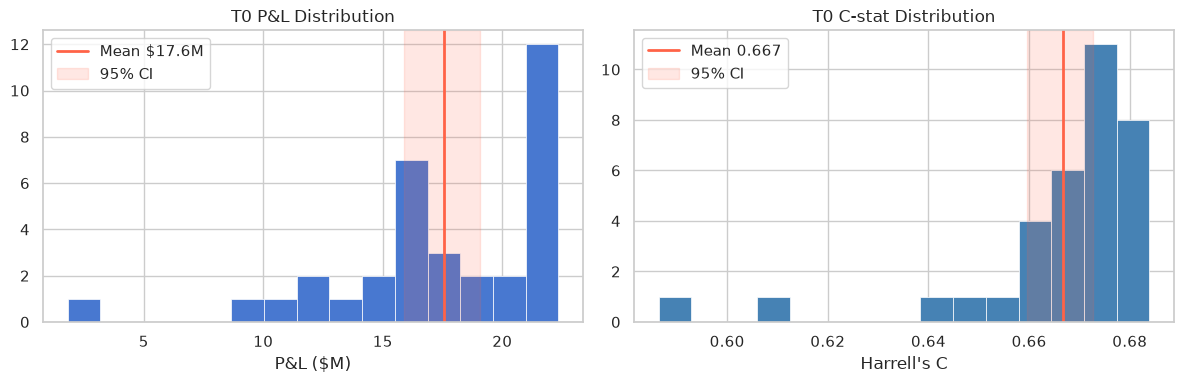

P&L  95% CI: $15.9M – $19.1M
C-stat 95% CI: 0.660 – 0.673


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# P&L
ax = axes[0]
ax.hist(df["pnl"] / 1e6, bins=15, edgecolor="white", linewidth=0.5)
mean_pnl, lo, hi = bootstrap_ci(df["pnl"])
ax.axvline(mean_pnl / 1e6, color="tomato", linewidth=2, label=f"Mean ${mean_pnl/1e6:.1f}M")
ax.axvspan(lo / 1e6, hi / 1e6, alpha=0.15, color="tomato", label="95% CI")
ax.set_xlabel("P&L ($M)")
ax.set_title("T0 P&L Distribution")
ax.legend()

# C-stat
ax = axes[1]
ax.hist(df["c_stat"], bins=15, edgecolor="white", linewidth=0.5, color="steelblue")
mean_c, lo_c, hi_c = bootstrap_ci(df["c_stat"])
ax.axvline(mean_c, color="tomato", linewidth=2, label=f"Mean {mean_c:.3f}")
ax.axvspan(lo_c, hi_c, alpha=0.15, color="tomato", label="95% CI")
ax.set_xlabel("Harrell's C")
ax.set_title("T0 C-stat Distribution")
ax.legend()

plt.tight_layout()
plt.savefig("04_t0_analysis_graphs/t0_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"P&L  95% CI: ${lo/1e6:.1f}M – ${hi/1e6:.1f}M")
print(f"C-stat 95% CI: {lo_c:.3f} – {hi_c:.3f}")


## 3. Power Analysis — Is N=20 Enough?

In [7]:
pnl_sd = df["pnl"].std()
print(f"T0 P&L SD: ${pnl_sd/1e6:.2f}M")
print()
print("N required per group (two-sample t-test, 80% power, α=0.05):")
for effect_m in [1, 2, 3, 4, 5]:
    n = required_n(pnl_sd, effect_m * 1e6)
    print(f"  Detect ${effect_m}M difference → N = {n} per group")

print()
print("Current N=20 can reliably detect differences of:")
from scipy import stats
z_alpha = stats.norm.ppf(0.975)
z_beta  = stats.norm.ppf(0.80)
detectable = (z_alpha + z_beta) * pnl_sd * np.sqrt(2 / 20)
print(f"  ~${detectable/1e6:.1f}M  (80% power, α=0.05, N=20 per group)")


T0 P&L SD: $4.79M

N required per group (two-sample t-test, 80% power, α=0.05):
  Detect $1M difference → N = 361 per group
  Detect $2M difference → N = 91 per group
  Detect $3M difference → N = 41 per group
  Detect $4M difference → N = 23 per group
  Detect $5M difference → N = 15 per group

Current N=20 can reliably detect differences of:
  ~$4.2M  (80% power, α=0.05, N=20 per group)


## 4. Outlier Identification

In [8]:
outliers = outlier_report(df)
print(f"{len(outliers)} outlier episodes (|z| > 2.0 on P&L or C-stat):")
display(outliers)


3 outlier episodes (|z| > 2.0 on P&L or C-stat):


,episode_id,pnl,c_stat,approach,flag_pnl,flag_cstat
8,8,1821023.940,0.678,Logistic regression default risk model with gr...,True,False
10,10,21757738.984,0.610,Logistic regression risk model trained on 466k...,False,True
30,30,16185108.930,0.586,Logistic regression default risk model with gr...,False,True


In [9]:
# For traced outliers, show approach + hypothesis
traced_outliers = outliers[outliers["episode_id"].apply(lambda e: has_trace(TREATMENT, e))]
if not traced_outliers.empty:
    print("Outliers WITH traces (can deep-dive):")
    for _, row in traced_outliers.iterrows():
        ep = int(row["episode_id"])
        full = df[df["episode_id"] == ep].iloc[0]
        print(f"\nep{ep:04d} | P&L ${full['pnl']/1e6:.1f}M | C={full['c_stat']:.3f}")
        print(f"  Approach:    {full['approach']}")
        print(f"  Hypothesis:  {full['hypothesis']}")
else:
    print("No traced outliers — autopsy via skill_dir scripts only.")


Outliers WITH traces (can deep-dive):

ep0030 | P&L $16.2M | C=0.586
  Approach:    Logistic regression default risk model with grade-based risk pricing (C-F grades, base rates C=21%, D=23%, E=27%, F=30% + 20% risk premium), acceptance via sensitivity model, greedy capital allocation under $15M cap
  Hypothesis:  Higher-risk grades E-F with risk-adjusted pricing at 27-36% rates yield the best risk-adjusted returns while maintaining acceptable acceptance rates


## 5. Strategy Patterns (all episodes)

In [10]:
# Keyword extraction from approach strings
keywords = {
    "logistic":       r"logistic",
    "gradient_boost": r"gradient boost|gbm|xgboost|lightgbm|catboost",
    "random_forest":  r"random forest",
    "cox":            r"cox",
    "survival_nn":    r"deephit|coxph_nn|pchazard|torchsurv",
    "grade_based":    r"grade.based|grade.pric|by.grade",
    "risk_adjusted":  r"risk.adjust|risk.score|risk.based",
    "cap_hit":        r"\$15m|capital cap|cap hit|15,000,000",
}

import re
for label, pattern in keywords.items():
    matches = df["approach"].str.contains(pattern, case=False, regex=True).sum()
    pct = 100 * matches / len(df)
    print(f"  {label:20s}: {matches:3d}/{len(df)}  ({pct:.0f}%)")


  logistic            :  24/34  (71%)
  gradient_boost      :   3/34  (9%)
  random_forest       :   0/34  (0%)
  cox                 :   1/34  (3%)
  survival_nn         :   0/34  (0%)
  grade_based         :   8/34  (24%)
  risk_adjusted       :  13/34  (38%)
  cap_hit             :  25/34  (74%)


In [11]:
# P&L by primary model family
df["model_family"] = "other"
df.loc[df["approach"].str.contains(r"logistic", case=False), "model_family"] = "logistic"
df.loc[df["approach"].str.contains(r"gradient boost|gbm|xgboost|lightgbm", case=False), "model_family"] = "gbm"
df.loc[df["approach"].str.contains(r"random forest", case=False), "model_family"] = "random_forest"
df.loc[df["approach"].str.contains(r"cox", case=False), "model_family"] = "cox"

print("Mean P&L by detected model family:")
display(df.groupby("model_family")["pnl"].agg(["count", "mean", "std"]).round(0))


Mean P&L by detected model family:


,count,mean,std
model_family,,,
cox,1,22203586.000,NaN
gbm,3,18748559.000,4045646.000
logistic,24,16987520.000,5289435.000
other,6,18486856.000,2929965.000


## 6. Trace Analysis (ep0014–ep0033)

In [12]:
traced_ids = [eid for eid in df["episode_id"] if has_trace(TREATMENT, eid)]
print(f"{len(traced_ids)} episodes with traces: {traced_ids}")


20 episodes with traces: [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


In [13]:
# Build per-episode trace feature table (takes ~30s)
print("Loading trace features... (may take ~30s)")
trace_df = treatment_trace_df(TREATMENT, traced_ids)
display(trace_df[["episode_id","pnl","c_stat","models_used","tool_calls","errors","timeouts","summarizations","overflow_recoveries"]].to_string())


Loading trace features... (may take ~30s)


'    episode_id          pnl  c_stat                                                          models_used  tool_calls  errors  timeouts  summarizations  overflow_recoveries\n0           14 22114419.470   0.674                               [lifelines_cox, logistic, sklearn_gbm]          77      40         3               4                    0\n1           15 22348721.207   0.675                                                           [logistic]          27       6         3               1                    0\n2           16 17615560.053   0.683                           [lightgbm, logistic, sklearn_gbm, xgboost]          64      22         4               3                    0\n3           17 19540360.411   0.663                                                           [logistic]          36      19         4               2                    0\n4           18 16294029.063   0.674                                     [logistic, sklearn_gbm, xgboost]          71      33         2

In [18]:
for index, row in trace_df.iterrows():
    print(f"---------------------------")
    for col in row.index:
        print(f"{col}: {row[col]}")
    print(f"---------------------------")

---------------------------
episode_id: 14
has_trace: True
pnl: 22114419.47
c_stat: 0.6742
acceptance_rate: 0.7532
loans_funded: 810
approach: HistGradientBoosting default risk model (34 features) with grade-aware pricing, capital cap at $15M, greedy selection by expected P&L per principal
hypothesis: Higher default probability borrowers should be offered higher rates to maximize expected P&L while maintaining acceptance rates above 1%
models_used: ['lifelines_cox', 'logistic', 'sklearn_gbm']
tool_calls: 77
errors: 40
timeouts: 3
summarizations: 4
overflow_recoveries: 0
thinking_turns: 0
trace_tokens: 1790542
---------------------------
---------------------------
episode_id: 15
has_trace: True
pnl: 22348721.20731087
c_stat: 0.6754496064597552
acceptance_rate: 0.1997658998293228
loans_funded: 751
approach: Offered 36% APR to all applicants; used logistic regression default probability model (C-stat=0.675) trained on 466k historical loans; selected loans by expected P&L per dollar until

In [ ]:
# Model usage frequency across traced episodes
from collections import Counter
all_models = [m for models in trace_df["models_used"] for m in models]
model_counts = Counter(all_models)
print("Model usage across traced episodes:")
for model, count in model_counts.most_common():
    print(f"  {model:25s}: {count}/{len(trace_df)} episodes")


In [ ]:
# Error / timeout rates
print(f"Mean tool calls per episode:     {trace_df['tool_calls'].mean():.1f}")
print(f"Mean errors per episode:         {trace_df['errors'].mean():.1f}")
print(f"Mean timeouts per episode:       {trace_df['timeouts'].mean():.1f}")
print(f"Episodes with summarization:     {(trace_df['summarizations'] > 0).sum()}/{len(trace_df)}")
print(f"Episodes with overflow recovery: {(trace_df['overflow_recoveries'] > 0).sum()}/{len(trace_df)}")


## 7. High Performer vs Low Performer Analysis

In [ ]:
top_q    = df["pnl"].quantile(0.75)
bottom_q = df["pnl"].quantile(0.25)

top    = df[df["pnl"] >= top_q]
bottom = df[df["pnl"] <= bottom_q]

print(f"Top quartile (≥${top_q/1e6:.1f}M):    {len(top)} episodes")
print(f"Bottom quartile (≤${bottom_q/1e6:.1f}M): {len(bottom)} episodes")
print()
print("TOP QUARTILE approaches:")
for _, row in top.sort_values("pnl", ascending=False).iterrows():
    print(f"  ep{int(row['episode_id']):04d} ${row['pnl']/1e6:.1f}M: {row['approach'][:100]}")
print()
print("BOTTOM QUARTILE approaches:")
for _, row in bottom.sort_values("pnl").iterrows():
    print(f"  ep{int(row['episode_id']):04d} ${row['pnl']/1e6:.1f}M: {row['approach'][:100]}")


## 8. Outlier Deep Dive (Trace Walkthrough)

Change `DEEP_DIVE_EP` to the episode you want to explore.

In [ ]:
DEEP_DIVE_EP = 29  # change to any traced outlier episode

if not has_trace(TREATMENT, DEEP_DIVE_EP):
    print(f"ep{DEEP_DIVE_EP:04d} has no trace. Check skill_dir scripts instead:")
    import os
    skill = f"results/skills/treatment_{TREATMENT}/episode_{DEEP_DIVE_EP:04d}/"
    for f in sorted(os.listdir(skill)):
        print(f"  {f}")
else:
    trace = load_trace(TREATMENT, DEEP_DIVE_EP)
    ep_row = df[df["episode_id"] == DEEP_DIVE_EP].iloc[0]
    print(f"ep{DEEP_DIVE_EP:04d} | P&L ${ep_row['pnl']/1e6:.1f}M | C={ep_row['c_stat']:.3f}")
    print(f"Approach: {ep_row['approach']}")
    print(f"\n{len(trace)} messages | Models: {detect_models(trace)}")
    errors = count_errors(trace)
    print(f"Errors: {errors['errors']} | Timeouts: {errors['timeouts']}")
    print("\n--- TOOL CALL SEQUENCE ---")
    for msg in trace:
        if msg["type"] == "AIMessage" and msg.get("tool_calls"):
            for tc in msg["tool_calls"]:
                code_preview = str(tc["args"].get("code", ""))[:80].replace("\n", " ")
                print(f"  turn {msg['turn']:3d} [{msg['ts']}] → {tc['name']}({code_preview}...)")
        elif msg["type"] == "ToolMessage":
            content_preview = str(msg.get("content",""))[:100].replace("\n", " ")
            print(f"           result: {content_preview}")
        elif msg["type"] == "HumanMessage" and msg.get("source") == "summarization":
            print(f"  turn {msg['turn']:3d} *** SUMMARIZATION FIRED ***")


In [ ]:
# Show thinking blocks for deep dive episode
if has_trace(TREATMENT, DEEP_DIVE_EP):
    thoughts = extract_thinking(load_trace(TREATMENT, DEEP_DIVE_EP))
    print(f"{len(thoughts)} thinking blocks")
    for i, t in enumerate(thoughts[:3]):  # first 3
        print(f"\n=== Thinking block {i+1} ===")
        print(t[:1000])
        if len(t) > 1000:
            print(f"... ({len(t)} chars total)")
